# Chapter 10: Single-Cell and Spatial Omics Agents

## Hands-On Jupyter Notebook

This notebook simulates agentic analysis of single-cell and spatial omics data using synthetic cell neighborhoods and marker-driven reasoning.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A synthetic single-cell and spatial transcriptomics panel
- A cell-identity agent that interprets marker programs
- A neighborhood enrichment summary for tissue regions
- Exercises for identity scoring and hotspot detection

---

## Section 1: Setup and Imports

We configure plotting and deterministic synthetic data generation for spatial omics simulations.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 10 single-cell/spatial notebook.')

Environment configured for Chapter 10 single-cell/spatial notebook.


## Section 2: Synthetic Cells and Spatial Coordinates

We create a small cell atlas with marker measurements and tissue coordinates.

In [2]:
cells_df = pd.DataFrame(
    [
        {'cell_id': 'sc_01', 'x': 1, 'y': 2, 'EPCAM': 8.4, 'PTPRC': 0.8, 'COL1A1': 1.1, 'MKI67': 1.2},
        {'cell_id': 'sc_02', 'x': 2, 'y': 3, 'EPCAM': 7.9, 'PTPRC': 1.0, 'COL1A1': 1.4, 'MKI67': 4.5},
        {'cell_id': 'sc_03', 'x': 3, 'y': 1, 'EPCAM': 1.2, 'PTPRC': 7.8, 'COL1A1': 1.0, 'MKI67': 0.9},
        {'cell_id': 'sc_04', 'x': 4, 'y': 4, 'EPCAM': 0.9, 'PTPRC': 6.9, 'COL1A1': 1.3, 'MKI67': 1.4},
        {'cell_id': 'sc_05', 'x': 5, 'y': 2, 'EPCAM': 1.0, 'PTPRC': 1.1, 'COL1A1': 8.0, 'MKI67': 0.7},
        {'cell_id': 'sc_06', 'x': 6, 'y': 3, 'EPCAM': 1.2, 'PTPRC': 1.0, 'COL1A1': 7.4, 'MKI67': 0.8},
        {'cell_id': 'sc_07', 'x': 7, 'y': 1, 'EPCAM': 6.8, 'PTPRC': 1.4, 'COL1A1': 1.0, 'MKI67': 2.2},
        {'cell_id': 'sc_08', 'x': 8, 'y': 4, 'EPCAM': 1.3, 'PTPRC': 6.5, 'COL1A1': 1.2, 'MKI67': 3.7},
    ]
)

display(cells_df)

,cell_id,x,y,EPCAM,PTPRC,COL1A1,MKI67
0,sc_01,1,2,8.4,0.8,1.1,1.2
1,sc_02,2,3,7.9,1.0,1.4,4.5
2,sc_03,3,1,1.2,7.8,1.0,0.9
3,sc_04,4,4,0.9,6.9,1.3,1.4
4,sc_05,5,2,1.0,1.1,8.0,0.7
5,sc_06,6,3,1.2,1.0,7.4,0.8
6,sc_07,7,1,6.8,1.4,1.0,2.2
7,sc_08,8,4,1.3,6.5,1.2,3.7


## Section 3: Identity and Neighborhood Analysis

We infer cell identities from marker programs and summarize neighborhood composition by tissue region.

In [3]:
def assign_cell_type(row: pd.Series) -> str:
    marker_map = {
        'epithelial': row['EPCAM'],
        'immune': row['PTPRC'],
        'stromal': row['COL1A1'],
    }
    return max(marker_map, key=marker_map.get)

cells_df['cell_type'] = cells_df.apply(assign_cell_type, axis=1)
cells_df['cycling_score'] = cells_df['MKI67'].round(2)
cells_df['region'] = np.where(cells_df['x'] <= 4, 'left_tissue', 'right_tissue')

identity_summary = cells_df.groupby(['cell_type', 'region'], as_index=False).agg(cells=('cell_id', 'count'), avg_cycling=('cycling_score', 'mean'))
display(cells_df)
display(identity_summary)

,cell_id,x,y,EPCAM,PTPRC,COL1A1,MKI67,cell_type,cycling_score,region
0,sc_01,1,2,8.4,0.8,1.1,1.2,epithelial,1.2,left_tissue
1,sc_02,2,3,7.9,1.0,1.4,4.5,epithelial,4.5,left_tissue
2,sc_03,3,1,1.2,7.8,1.0,0.9,immune,0.9,left_tissue
3,sc_04,4,4,0.9,6.9,1.3,1.4,immune,1.4,left_tissue
4,sc_05,5,2,1.0,1.1,8.0,0.7,stromal,0.7,right_tissue
5,sc_06,6,3,1.2,1.0,7.4,0.8,stromal,0.8,right_tissue
6,sc_07,7,1,6.8,1.4,1.0,2.2,epithelial,2.2,right_tissue
7,sc_08,8,4,1.3,6.5,1.2,3.7,immune,3.7,right_tissue


,cell_type,region,cells,avg_cycling
0,epithelial,left_tissue,2,2.85
1,epithelial,right_tissue,1,2.20
2,immune,left_tissue,2,1.15
3,immune,right_tissue,1,3.70
4,stromal,right_tissue,2,0.75


## Section 5: Exercises

### Exercise 1: Identity Scoring

Build a marker score and identify the strongest cell identity for each cell.

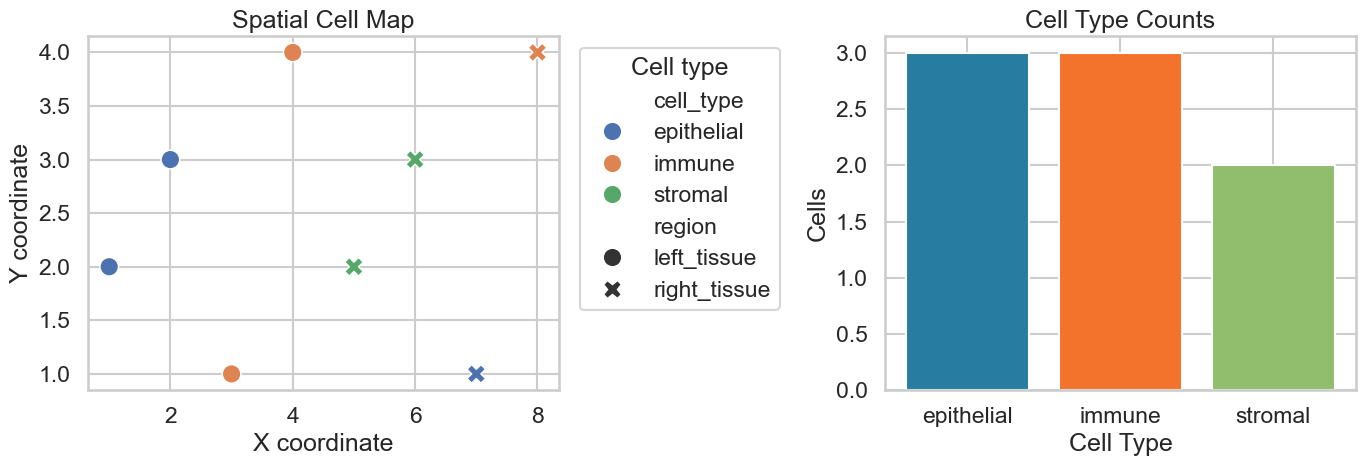

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=cells_df, x='x', y='y', hue='cell_type', style='region', s=180, ax=axes[0])
axes[0].set_title('Spatial Cell Map')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')
axes[0].legend(title='Cell type', bbox_to_anchor=(1.02, 1), loc='upper left')

type_counts = cells_df['cell_type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['#277DA1', '#F3722C', '#90BE6D'])
axes[1].set_title('Cell Type Counts')
axes[1].set_xlabel('Cell Type')
axes[1].set_ylabel('Cells')

plt.tight_layout()
plt.show()

## Section 4: Visualization

We visualize spatial position, cell identity, and the relative abundance of each program.

In [5]:
def score_cell_identity(row: pd.Series) -> dict[str, object]:
    scores = {
        'epithelial': row['EPCAM'] + 0.1 * row['MKI67'],
        'immune': row['PTPRC'] + 0.1 * row['MKI67'],
        'stromal': row['COL1A1'] + 0.1 * row['MKI67'],
    }
    best = max(scores, key=scores.get)
    return {'predicted_identity': best, 'identity_score': round(scores[best], 2)}

identity_scores = pd.DataFrame([score_cell_identity(r) for _, r in cells_df.iterrows()])
exercise1_df = pd.concat([cells_df[['cell_id']], identity_scores], axis=1)
display(exercise1_df)

,cell_id,predicted_identity,identity_score
0,sc_01,epithelial,8.52
1,sc_02,epithelial,8.35
2,sc_03,immune,7.89
3,sc_04,immune,7.04
4,sc_05,stromal,8.07
5,sc_06,stromal,7.48
6,sc_07,epithelial,7.02
7,sc_08,immune,6.87


### Exercise 2: Neighborhood Hotspots

Detect tissue regions where epithelial and immune cells co-occur at elevated levels.

In [6]:
hotspot_df = (
    cells_df.groupby('region', as_index=False)
    .agg(
        epithelial_cells=('cell_type', lambda s: (s == 'epithelial').sum()),
        immune_cells=('cell_type', lambda s: (s == 'immune').sum()),
        stromal_cells=('cell_type', lambda s: (s == 'stromal').sum()),
    )
)
hotspot_df['hotspot_score'] = hotspot_df['epithelial_cells'] + hotspot_df['immune_cells']
hotspot_df = hotspot_df.sort_values('hotspot_score', ascending=False).reset_index(drop=True)

display(hotspot_df)

,region,epithelial_cells,immune_cells,stromal_cells,hotspot_score
0,left_tissue,2,2,0,4
1,right_tissue,1,1,2,2


## Section 6: Key Takeaways

- Single-cell agents benefit from explicit marker-to-identity rules.
- Spatial coordinates add context for neighborhood-aware reasoning.
- Region summaries make cell-state patterns easier to operationalize.
- Hotspot detection helps prioritize tissue areas for follow-up analysis.
- Structured outputs make downstream atlas QA reproducible.


## Next Steps

1. Add more markers and mixed-lineage states.
2. Extend the spatial analysis to cell-cell interaction scoring.
3. Connect Chapter 10 neighborhoods to Chapter 11 graph reasoning.
4. Replace the synthetic atlas with real count matrices when available.


**Last Updated**: May 2026